In [1]:
# Customer Segmentation Analysis
# Oasis Infobyte - Data Analytics - Task 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Online Retail dataset

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

import zipfile
import io
import requests

response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))

print(z.namelist())

df = pd.read_excel(z.open("Online Retail.xlsx"))

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


['Online Retail.xlsx']
Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Step 3: Inspect and clean the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Step 4: Clean the dataset

# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Keep only positive Quantity and UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned Dataset Shape:", df.shape)
print("Missing Customer IDs:", df["CustomerID"].isnull().sum())

display(df.head())


Cleaned Dataset Shape: (397884, 9)
Missing Customer IDs: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
# Step 4: Clean the dataset

# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Keep only positive Quantity and UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned Dataset Shape:", df.shape)
print("Missing Customer IDs:", df["CustomerID"].isnull().sum())

display(df.head())

Cleaned Dataset Shape: (397884, 9)
Missing Customer IDs: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [6]:
# Step 5: Create RFM features

# Snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Average Purchase Value
rfm["AveragePurchaseValue"] = rfm["Monetary"] / rfm["Frequency"]

# Historical Customer Lifetime Value (CLV proxy)
rfm["CustomerLifetimeValue"] = rfm["Monetary"]

print("RFM Analysis Created!")
print("Number of Customers:", len(rfm))

display(rfm.head())

RFM Analysis Created!
Number of Customers: 4338


,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
CustomerID,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60
12347.0,2,7,4310.00,615.714286,4310.00
12348.0,75,4,1797.24,449.310000,1797.24
12349.0,19,1,1757.55,1757.550000,1757.55
12350.0,310,1,334.40,334.400000,334.40


In [7]:
# Step 6: RFM statistics

print("RFM Statistical Summary:")
display(rfm.describe())

# Check skewness
print("\nSkewness:")
display(rfm[["Recency", "Frequency", "Monetary"]].skew())

RFM Statistical Summary:


,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460,419.166289,2054.266460
std,100.014169,7.697998,8989.230441,1796.537944,8989.230441
min,1.000000,1.000000,3.750000,3.450000,3.750000
25%,18.000000,1.000000,307.415000,178.625000,307.415000
50%,51.000000,2.000000,674.485000,293.900000,674.485000
75%,142.000000,5.000000,1661.740000,430.113750,1661.740000
max,374.000000,209.000000,280206.020000,84236.250000,280206.020000



Skewness:


,0
Recency,1.246048
Frequency,12.067031
Monetary,19.324953


In [8]:
# Step 7: Log transform and standardize RFM features

rfm_features = ["Recency", "Frequency", "Monetary"]

# Log transformation to reduce skewness
rfm_log = np.log1p(rfm[rfm_features])

# Standardization
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_features,
    index=rfm.index
)

print("RFM features standardized successfully!")

display(rfm_scaled.head())

RFM features standardized successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962


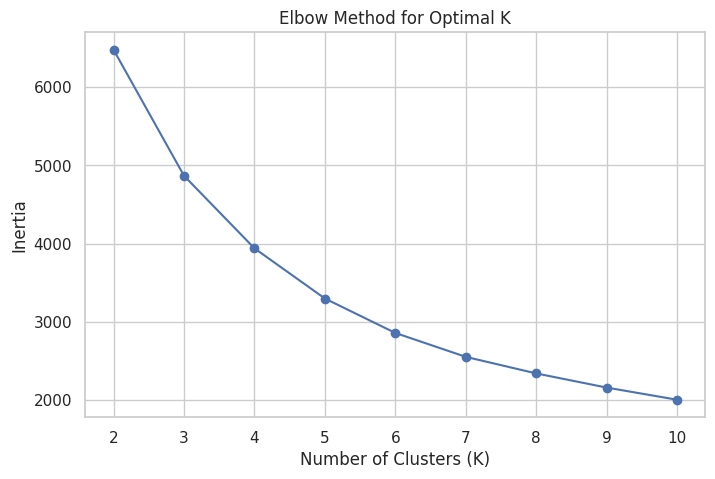

In [9]:
# Step 8: Elbow Method to find optimal K

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 11))
plt.show()


In [10]:
# Step 9: Apply K-Means Clustering

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed!")
print("Number of clusters:", optimal_k)

display(rfm.head())

K-Means clustering completed!
Number of clusters: 4


,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,Cluster
CustomerID,,,,,,
12346.0,326,1,77183.60,77183.600000,77183.60,2
12347.0,2,7,4310.00,615.714286,4310.00,1
12348.0,75,4,1797.24,449.310000,1797.24,2
12349.0,19,1,1757.55,1757.550000,1757.55,0
12350.0,310,1,334.40,334.400000,334.40,3


In [11]:
# Step 10: Cluster Profiling

cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "AveragePurchaseValue": "mean",
    "CustomerLifetimeValue": "mean"
}).round(2)

cluster_profile["CustomerCount"] = rfm.groupby("Cluster").size()

print("Cluster Profile:")
display(cluster_profile)

Cluster Profile:


,Recency,Frequency,Monetary,AveragePurchaseValue,CustomerLifetimeValue,CustomerCount
Cluster,,,,,,
0,18.12,2.15,551.82,282.11,551.82,837
1,12.13,13.71,8074.27,623.51,8074.27,716
2,71.08,4.08,1802.83,577.42,1802.83,1173
3,182.50,1.32,343.45,284.42,343.45,1612


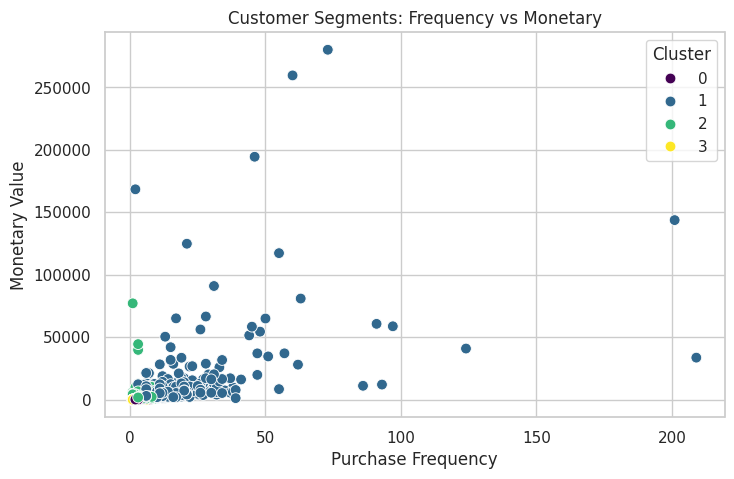

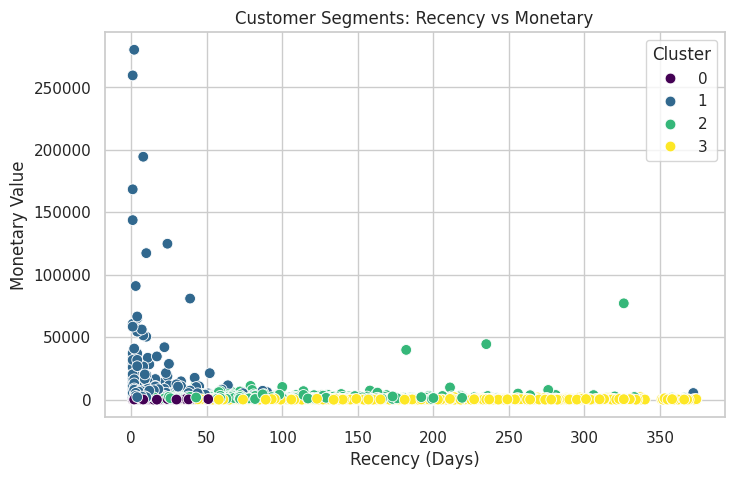

In [12]:
# Step 11: Cluster Visualization

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.show()


plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=60
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")
plt.show()

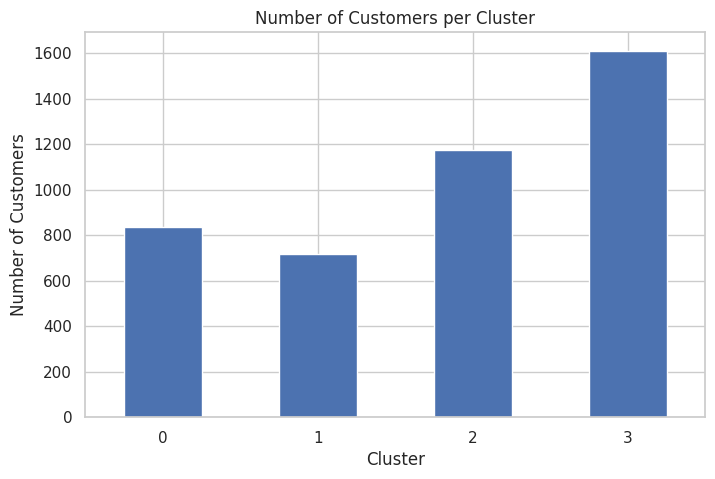

,CustomerCount
Cluster,
0,837
1,716
2,1173
3,1612


In [13]:
# Step 12: Number of Customers per Cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

display(cluster_counts.to_frame("CustomerCount"))

In [14]:
# Step 13: Customer Segment Interpretation

segment_names = {
    0: "Active Low-Value Customers",
    1: "High-Value Loyal Customers",
    2: "At-Risk Customers",
    3: "Inactive Low-Value Customers"
}

marketing_actions = {
    0: "Encourage repeat purchases with personalized offers and product recommendations.",
    1: "Reward loyalty with VIP offers, exclusive products, and retention campaigns.",
    2: "Use win-back campaigns, reminders, and limited-time discounts.",
    3: "Use re-engagement campaigns and targeted offers to bring customers back."
}

segment_summary = cluster_profile.copy()

segment_summary["Segment"] = segment_summary.index.map(segment_names)
segment_summary["MarketingAction"] = segment_summary.index.map(marketing_actions)

segment_summary = segment_summary[
    ["Segment", "CustomerCount", "Recency", "Frequency",
     "Monetary", "AveragePurchaseValue", "MarketingAction"]
]

display(segment_summary)

,Segment,CustomerCount,Recency,Frequency,Monetary,AveragePurchaseValue,MarketingAction
Cluster,,,,,,,
0,Active Low-Value Customers,837,18.12,2.15,551.82,282.11,Encourage repeat purchases with personalized o...
1,High-Value Loyal Customers,716,12.13,13.71,8074.27,623.51,"Reward loyalty with VIP offers, exclusive prod..."
2,At-Risk Customers,1173,71.08,4.08,1802.83,577.42,"Use win-back campaigns, reminders, and limited..."
3,Inactive Low-Value Customers,1612,182.50,1.32,343.45,284.42,Use re-engagement campaigns and targeted offer...


In [15]:
# Step 14: Final Business Insights

print("KEY BUSINESS INSIGHTS")
print("-" * 60)

print("""
1. High-Value Loyal Customers:
   These customers purchase frequently and generate high monetary value.
   Focus on loyalty rewards, VIP offers, and retention campaigns.

2. Active Low-Value Customers:
   These customers are recently active but have lower purchase frequency
   and monetary value. Encourage repeat purchases using personalized offers.

3. At-Risk Customers:
   These customers have not purchased recently. Use reminders, win-back
   campaigns, and limited-time offers to encourage them to return.

4. Inactive Low-Value Customers:
   These customers have high recency and low purchase activity.
   Use targeted re-engagement campaigns to reactivate them.

5. K-Means clustering successfully divided customers into 4 segments
   using Recency, Frequency, and Monetary (RFM) behavior.
""")

KEY BUSINESS INSIGHTS
------------------------------------------------------------

1. High-Value Loyal Customers:
   These customers purchase frequently and generate high monetary value.
   Focus on loyalty rewards, VIP offers, and retention campaigns.

2. Active Low-Value Customers:
   These customers are recently active but have lower purchase frequency
   and monetary value. Encourage repeat purchases using personalized offers.

3. At-Risk Customers:
   These customers have not purchased recently. Use reminders, win-back
   campaigns, and limited-time offers to encourage them to return.

4. Inactive Low-Value Customers:
   These customers have high recency and low purchase activity.
   Use targeted re-engagement campaigns to reactivate them.

5. K-Means clustering successfully divided customers into 4 segments
   using Recency, Frequency, and Monetary (RFM) behavior.



In [16]:
# Step 15: Save Customer Segmentation Results

final_data = rfm.copy()

final_data["Segment"] = final_data["Cluster"].map(segment_names)

final_data.to_csv(
    "customer_segmentation_results.csv",
    index=True
)

print("Customer segmentation results saved successfully!")
print("File: customer_segmentation_results.csv")

Customer segmentation results saved successfully!
File: customer_segmentation_results.csv


In [17]:
# Step 16: Final Conclusion

print("""
CONCLUSION
----------

Customer segmentation was performed using RFM analysis and K-Means clustering.

The customers were divided into 4 segments based on:
- Recency
- Frequency
- Monetary Value

The analysis identified high-value loyal customers, active low-value customers,
at-risk customers, and inactive low-value customers.

These segments can help businesses create targeted marketing strategies,
improve customer retention, and increase customer engagement.
""")


CONCLUSION
----------

Customer segmentation was performed using RFM analysis and K-Means clustering.

The customers were divided into 4 segments based on:
- Recency
- Frequency
- Monetary Value

The analysis identified high-value loyal customers, active low-value customers,
at-risk customers, and inactive low-value customers.

These segments can help businesses create targeted marketing strategies,
improve customer retention, and increase customer engagement.

